# 2025/2026: Ma513 — Session 4: Supervised and Unsupervised ML for  Network anomaly detection

**Duration:** 2h  

**Tools:** Python, pandas, numpy, matplotlib, scikit-learn.


> This lab follows the session 4 outline (Supervised and Unsupervised ML for network anomaly detection). The `scikit-learn` documentation is complete and should be consulted whenever necessary.

From what we have described during the respective lesson, it is not advisable to exclusively rely on automated tools for network anomaly detection, but it may be more productive to adopt ML algorithms that are able to dynamically learn how to recognize the presence of any anomalies within the network traffic, thus allowing the analyst to perform an in-depth analysis of only really suspicious cases. In this lab session,we will demonstrate the use of different ML algorithms for network anomaly detection, which can also be used to identify a botnet.

## 1. Network logs - 1:

In this exercise, considering the dataset `network-logs.csv`, the selected features are the values of network latency and network throughput. In our threat model, anomalous values associated with these features can be considered as representative of the presence of a botnet.

Different algorithms will be adopted to detect the anomalies. The accuracy of each algorithm will be calculated, in order to be able to make comparisons between the obtained results.

1. Start by importing the relevant libraries and the dataset.

In [19]:
# TODO: Your code
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from gaussian_anomaly_detection import GaussianAnomalyDetection
import matplotlib.pyplot as plt

2. Extract **LATENCY** as well as **THROUGHPUT** fields as samples then **ANOMALY** as targets.

In [3]:
# TODO: Your code
df = pd.read_csv("network-logs.csv")
latency = df["LATENCY"]
throughput = df["THROUGHPUT"]
anomaly = df["ANOMALY"]

3. Split samples and targets into training samples, training_samples, test-ing_samples, training_targets and testing_targets. Then, fit a **classification tree** on your training dataset.

In [15]:
# TODO: Your code
training_samples, testing_samples, training_targets, testing_targets = train_test_split(df[['LATENCY', 'THROUGHPUT']], anomaly, test_size=0.3, random_state=42)
clf = DecisionTreeClassifier()
clf.fit(training_samples, training_targets)

DecisionTreeClassifier()

4. Use the obtained model to make a prediction then compute its accuracy score.

In [16]:
# TODO: Your code
clf.predict(testing_samples)
accuracy_score(testing_targets, clf.predict(testing_samples))

0.9344262295081968

5. Answer the previous two questions using a **random forest** model, a **k-Nearest Neighbors** model and a **Gaussian Naive Bayes** model.

In [17]:
# TODO: Your code

# Random Foret
rfm = RandomForestClassifier(n_estimators=100, random_state=42)
rfm.fit(training_samples, training_targets)
print("Random forest : ")
print(accuracy_score(testing_targets, rfm.predict(testing_samples)))

#K-NN
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(training_samples, training_targets)
print("KNN : ")
print(accuracy_score(testing_targets, knn.predict(testing_samples)))

# Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(training_samples, training_targets)
print("Gaussian : ")
print(accuracy_score(testing_targets, gnb.predict(testing_samples)))

Random forest : 
0.9590163934426229
KNN : 
0.9590163934426229
Gaussian : 
0.9836065573770492


6. By making the comparison between the obtained results, what do you conclude?

In [18]:
# TODO: Your answers here
# The gaussian is the best model (with 98% of accuracy) but the other model (such as RandomForest and KNN) are also really good

## 2. Network logs - 2:

In this exercise, we will consider the same previous dataset with the same selected features.

1. Verify whether the distribution of the samples might resemble a Gaussian distribution, displaying the corresponding values in the form of a histogram. At this point, is it then possible to use au Gaussian distribution to detect the anomalies? Justify your answer.

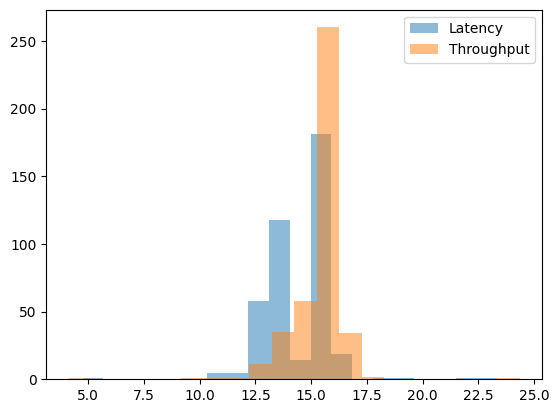

In [20]:
# TODO: Your code
plt.hist(latency, bins=20, alpha=0.5, label='Latency')
plt.hist(throughput, bins=20, alpha=0.5, label='Throughput')
plt.legend(loc='upper right')
plt.show()

2. Perform the data plotting on a scatter diagram, visually identifying the possible outliers. Based on the obtained output, describe what is seen visually.

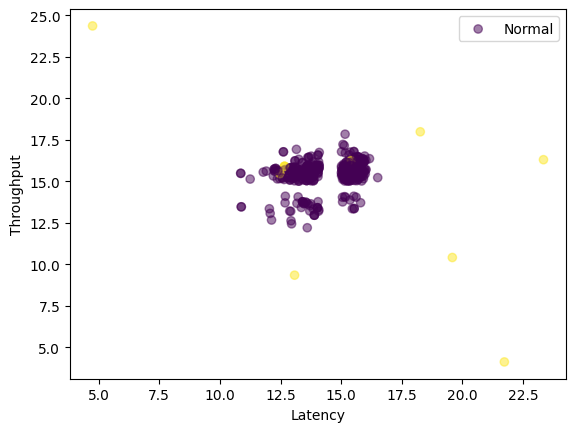

In [27]:
# TODO: Your code
plt.scatter(latency, throughput, alpha=0.5,cmap = 'viridis',c=anomaly)
plt.xlabel('Latency')
plt.ylabel('Throughput')
plt.legend(['Normal','Anomaly'])
plt.show()

In the following, we want to verify whether the anomalous cases are real, and then we proceed to estimate the representative values, 𝜇 and 𝜎, of the underlying Gaussian distribution $𝒩(𝜇,𝜎^2)$.

3. Thanks to the `GaussianAnomalyDetection` from the `gaussian_anomaly_detection module`, estimate the 𝜇 (mu) and 𝜎 (sigma) parameters.

In [31]:
# TODO: Your code
data = np.array([latency, throughput]).T
gad = GaussianAnomalyDetection(data)

4. Using again the `gaussian_anomaly_detection module`, proceed to estimate the probabilities and the threshold value, which we can then compare to identify the anomalous data.

In [50]:
# TODO: Your code
mu_param,sigma_squared = gad.estimate_gaussian(data)
print("Estimated mu : ", mu_param)
print("Estimated var : ", sigma_squared)
prob = gad.multivariate_gaussian(data)
print("Estimated probabilities : ",prob)
best_epsilon, best_f1, precision_history, recall_history, f1_history = gad.select_threshold(anomaly, prob.flatten())
print("Best epsilon : ", best_epsilon)
print("Best f1 : ", best_f1)
print("Precision history : ", precision_history)
print("Recall history : ", recall_history)
print("F1 history : ", f1_history)

Estimated mu :  [14.42070163 15.39209133]
Estimated var :  [2.09674794 1.37224807]
Estimated probabilities :  [[4.24929479e-02]
 [4.10156061e-02]
 [1.01417924e-02]
 [8.04173548e-02]
 [6.32331228e-02]
 [6.64170341e-02]
 [6.98760492e-02]
 [6.85770752e-02]
 [8.66794478e-02]
 [5.24825199e-02]
 [5.16652615e-02]
 [3.87563045e-02]
 [4.05435680e-02]
 [3.69976357e-02]
 [8.43883003e-02]
 [6.91327360e-02]
 [8.04619193e-02]
 [3.82539826e-02]
 [6.10400055e-02]
 [5.72224667e-02]
 [2.79513582e-02]
 [7.52403158e-02]
 [4.40922540e-02]
 [7.57281509e-02]
 [2.14783581e-02]
 [5.04854950e-02]
 [5.88227162e-02]
 [4.24929479e-02]
 [4.10156061e-02]
 [1.01417924e-02]
 [8.04173548e-02]
 [6.32331228e-02]
 [6.64170341e-02]
 [6.98760492e-02]
 [6.85770752e-02]
 [8.66794478e-02]
 [5.24825199e-02]
 [5.16652615e-02]
 [7.04748814e-02]
 [8.22855483e-02]
 [6.78791905e-02]
 [7.58651647e-02]
 [9.42696789e-03]
 [1.85095993e-02]
 [1.57708020e-02]
 [6.77337649e-02]
 [1.47472327e-02]
 [7.06295570e-02]
 [4.14473239e-02]
 [2.3351

5. Identify now the outliers by comparing the individual probabilities of the samples with the previously estimated optimal threshold value. Finally visualize their presence in a scatter diagram. Conclude.

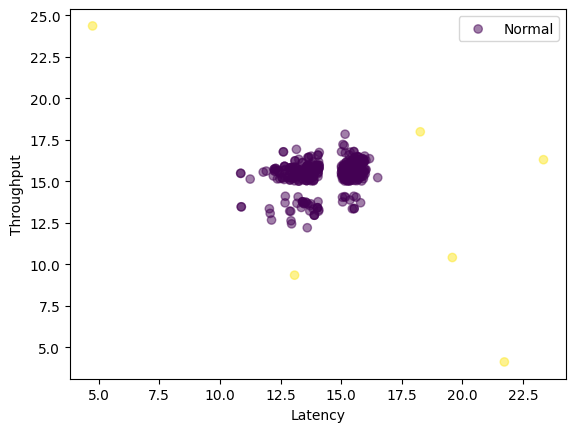

In [52]:
# TODO: Your code
outliers = prob.flatten() < best_epsilon
plt.scatter(latency, throughput, alpha=0.5,cmap = 'viridis',c=outliers)
plt.xlabel('Latency')
plt.ylabel('Throughput')
plt.legend(['Normal','Anomaly'])
plt.show()

## 3. Flows

In this exercise, you are given a synthetic network flow dataset (`flows.csv`) that simulates normal and anomalous network activities.
Each record represents a summary of one network connection (or flow) with features such as source/destination IPs, ports, protocol, packet counts, byte counts, duration, and TCP flags.
Your task is to apply Principal Component Analysis (PCA) to detect potential network anomalies without relying on labeled data.

1. Here are the required librairies.

In [53]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt

2. Load the dataset and analyze it.

In [54]:
# TODO: Your code
df = pd.read_csv("flows.csv")
df.head()

,timestamp,src_ip,dst_ip,proto,src_port,dst_port,duration_s,packets,bytes_out,bytes_in,flag_syn,flag_rst,label,scenario
0,2025-03-01 22:53:59,90.41.65.101,10.198.199.15,UDP,39349,5432,0.849862,31,3016,2355,0,0,0,normal
1,2025-03-01 13:56:22,10.139.74.145,93.80.109.103,UDP,51789,443,3.305759,80,4765,7162,0,0,0,normal
2,2025-03-01 12:33:11,10.196.63.42,10.253.42.16,TCP,45390,443,1.458122,64,3611,6225,0,0,0,normal
3,2025-03-01 05:26:21,10.78.194.248,82.52.215.53,TCP,52929,443,2.482954,64,2215,5442,0,0,0,normal
4,2025-03-01 12:09:02,10.116.41.180,10.18.152.75,TCP,29166,3389,0.869474,20,1482,479,0,0,0,normal


3. In the following, features selected for the PCA are firstly given a numeric format.

In [55]:
df["proto_tcp"] = (df["proto"] == "TCP").astype(int)
df["bytes_out_per_pkt"] = df["bytes_out"] / df["packets"].clip(lower=1)
df["bytes_in_per_pkt"] = df["bytes_in"] / df["packets"].clip(lower=1)
df["bytes_out_in_ratio"] = df["bytes_out"].clip(lower=1) / df["bytes_in"].clip(lower=1)
df["is_external_dst"] = (~df["dst_ip"].str.startswith("10.")).astype(int)

features = [
    "duration_s","packets","bytes_out","bytes_in",
    "bytes_out_per_pkt","bytes_in_per_pkt","bytes_out_in_ratio",
    "src_port","dst_port","proto_tcp","flag_syn","flag_rst","is_external_dst"
]
X = df[features].values
y = df["label"].values

4. Standardize the features, then fit a PCA model keeping 98% of variance.

In [72]:
# TODO: Your code
df.head()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

pca = PCA(n_components=0.98)
X_pca = pca.fit(X_scaled)

5. Once you fit PCA, it finds a set of principal components in your data that capture the most variance. Plot the explained variance ratio.(You can use `cumsum` function from numpy).

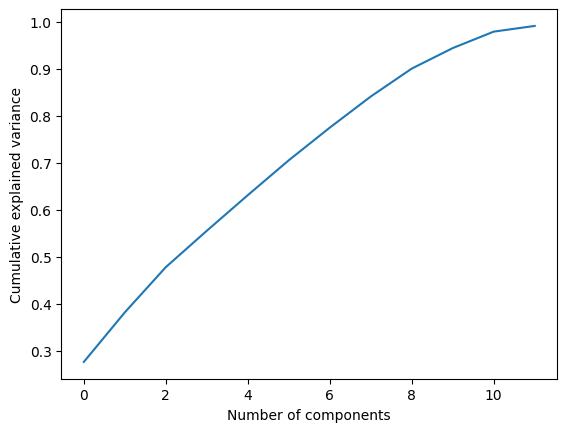

In [73]:
# TODO: Your code
np.cumsum(pca.explained_variance_ratio_)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.show()

6. Compute anomaly scores then plot a histogram of reconstruction errors.

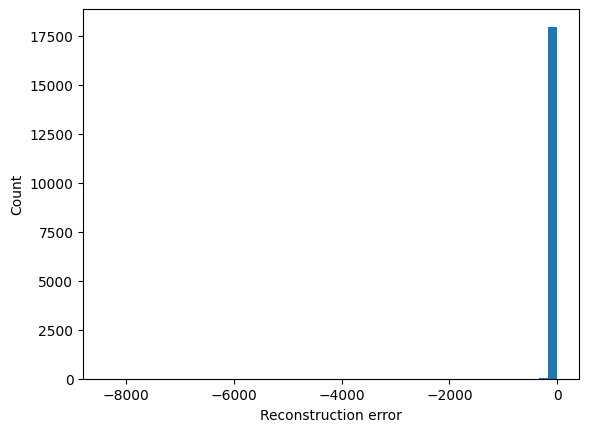

In [77]:
# TODO: Your code
score = pca.score_samples(X_scaled)
plt.hist(score, bins=50)
plt.xlabel('Reconstruction error')
plt.ylabel('Count')
plt.show()

7. Use the 99th percentile of the training reconstruction errors as a threshold to distinguish normal from anomalous flows.
Then, on the test data, compute the ROC-AUC score (to assess ranking quality) and the confusion matrix (to see how many anomalies were correctly detected).

In [80]:
# TODO: Your code
threshold = np.percentile(score, 99)
y_pred = (score > threshold).astype(int)
print(roc_auc_score(y, y_pred))
print(confusion_matrix(y, y_pred))

0.494375
[[15820   180]
 [ 2000     0]]
